# Redispatch volume analysis — ÜNB events 2013–2025

Two-part deep dive into the redispatch event data:

- **Part 1** uses **all** events (no plant match required) — fleet-wide volume, source mix, intra-day pattern, seasonality, size and duration distributions.
- **Part 2** uses **only events that joined to a geocoded plant** (`plant_matcher_output.xlsx`) — regional/TSO concentration, direction balance, congestion hotspots, hexbin heatmap.

Inputs:
- `2025-09-17 Redispatch Export 2013-2020.csv`
- `Redispatch_Daten(3).csv` (2021–2025)
- `plant_matcher_output.xlsx` (for Part 2 only)

Same cleaning conventions as the matching notebook — whitespace strip (kills the trailing-space duplicate in `RICHTUNG`), German date parse, comma→dot for numerics.

In [57]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = Path('.').resolve()
MATCHER_FILE = DATA_DIR / 'plant_matcher_output.xlsx'
REDISPATCH_FILES = [
    DATA_DIR / '2025-09-17 Redispatch Export 2013-2020.csv',
    DATA_DIR / 'Redispatch_Daten(3).csv',
]
for p in [MATCHER_FILE, *REDISPATCH_FILES]:
    assert p.exists(), p

CARRIER_COLORS = {'Konventionell': '#cc4b3a', 'Erneuerbar': '#3aa856', 'Sonstiges': '#888'}
TSO_COLORS = {'50Hertz': '#3a6ea5', 'Amprion': '#e09d3c',
              'TenneT TSO': '#cc4b3a', 'TransnetBW': '#6abf69'}

## Load + clean

The redispatch files have a phantom trailing space in some `RICHTUNG` values that splits one category in two — `.str.strip()` collapses it. Numeric columns use German `,` decimals and a few rows have stray text; we coerce with `errors='coerce'`.

In [58]:
def load_redispatch(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=';', encoding='utf-8',
                     on_bad_lines='skip', low_memory=False)
    for c in df.select_dtypes(include='object').columns:
        df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})
    df['ts_start'] = pd.to_datetime(
        df['BEGINN_DATUM'] + ' ' + df['BEGINN_UHRZEIT'].fillna('00:00'),
        format='%d.%m.%Y %H:%M', errors='coerce')
    df['ts_end'] = pd.to_datetime(
        df['ENDE_DATUM'] + ' ' + df['ENDE_UHRZEIT'].fillna('00:00'),
        format='%d.%m.%Y %H:%M', errors='coerce')
    df['duration_h'] = (df['ts_end'] - df['ts_start']).dt.total_seconds() / 3600
    for c in ['MITTLERE_LEISTUNG_MW', 'MAXIMALE_LEISTUNG_MW', 'GESAMTE_ARBEIT_MWH']:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.', regex=False),
                              errors='coerce')
    df['year'] = df['ts_start'].dt.year
    df['month'] = df['ts_start'].dt.month
    df['hour'] = df['ts_start'].dt.hour
    return df

rd = pd.concat([load_redispatch(p) for p in REDISPATCH_FILES], ignore_index=True)
print(f'rows: {len(rd):,}  |  span: {rd["ts_start"].min().date()} → {rd["ts_start"].max().date()}')
print(f'total redispatched energy: {rd["GESAMTE_ARBEIT_MWH"].sum()/1e6:.1f} TWh')

rows: 123,362  |  span: 2013-04-02 → 2026-06-22
total redispatched energy: 182.0 TWh


---

# Part 1 — All events

## 1.1 Year-over-year total redispatch

Two views: event count (how often the TSOs intervene) and dispatched energy (how big those interventions are). The two diverge — 2021 is the inflection point because the Redispatch 2.0 regime brings many more, smaller events into scope.

In [59]:
yoy = (rd.dropna(subset=['year'])
         .groupby('year')
         .agg(n_events=('GRUND_DER_MASSNAHME', 'size'),
              energy_twh=('GESAMTE_ARBEIT_MWH', lambda s: s.sum()/1e6),
              avg_mw=('MITTLERE_LEISTUNG_MW', 'mean'),
              avg_duration_h=('duration_h', 'mean'))
         .round(2))
yoy

,n_events,energy_twh,avg_mw,avg_duration_h
year,,,,
2013,2688,2.97,276.29,3.67
2014,3461,4.27,255.74,4.36
2015,6462,11.25,267.50,5.40
2016,4058,7.77,248.89,6.54
2017,5810,11.56,199.98,7.91
2018,5526,9.31,213.49,6.13
2019,5321,8.89,216.97,6.39
2020,6792,11.20,192.60,7.38
2021,8634,15.42,180.96,8.23


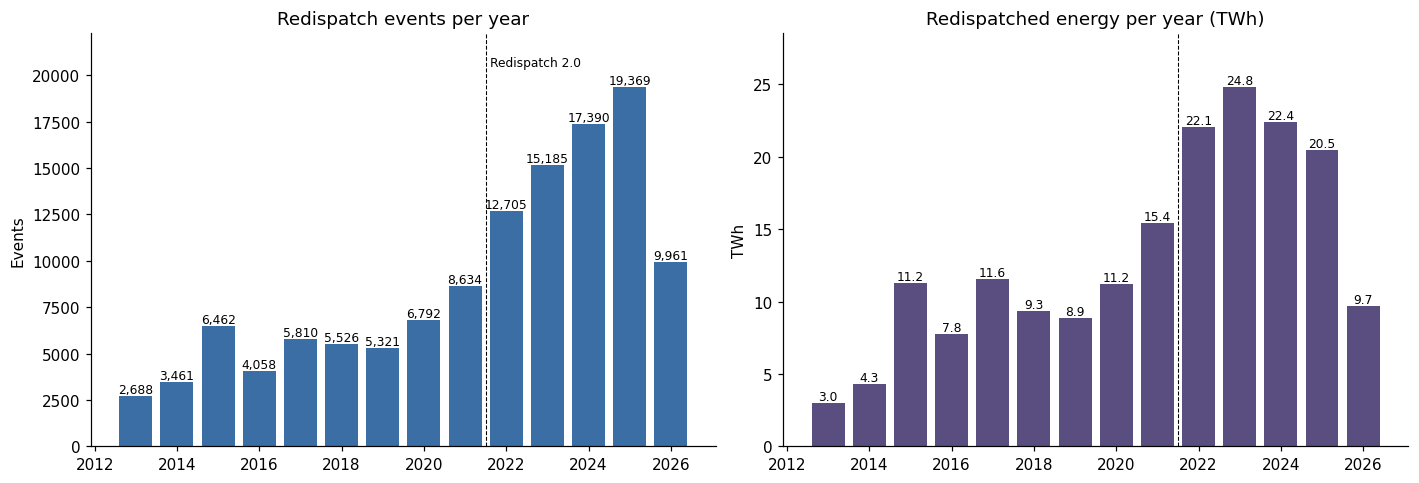

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(yoy.index, yoy['n_events'], color='#3a6ea5')
axes[0].set_title('Redispatch events per year')
axes[0].set_ylabel('Events')
for x, v in zip(yoy.index, yoy['n_events']):
    axes[0].annotate(f'{int(v):,}', (x, v), ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0, yoy['n_events'].max()*1.15)
axes[0].axvline(2021.5, color='k', ls='--', lw=0.7)
axes[0].text(2021.6, axes[0].get_ylim()[1]*0.92, 'Redispatch 2.0', fontsize=8)

axes[1].bar(yoy.index, yoy['energy_twh'], color='#5a4d80')
axes[1].set_title('Redispatched energy per year (TWh)')
axes[1].set_ylabel('TWh')
for x, v in zip(yoy.index, yoy['energy_twh']):
    axes[1].annotate(f'{v:.1f}', (x, v), ha='center', va='bottom', fontsize=8)
axes[1].set_ylim(0, yoy['energy_twh'].max()*1.15)
axes[1].axvline(2021.5, color='k', ls='--', lw=0.7)

plt.tight_layout(); plt.show()

## 1.2 Redispatch by source (`PRIMAERENERGIEART`)

Pre-2021 the curtailed-renewables side wasn't really in this dataset (DSO-level EinsMan was tracked separately). Post-Redispatch 2.0, renewables show up as a substantial share — that's a regime shift, not a real-world jump.

In [61]:
by_src = (rd.groupby('PRIMAERENERGIEART')
            .agg(n_events=('GRUND_DER_MASSNAHME','size'),
                 energy_twh=('GESAMTE_ARBEIT_MWH', lambda s: s.sum()/1e6),
                 avg_mw=('MITTLERE_LEISTUNG_MW','mean'),
                 median_duration_h=('duration_h','median')))
by_src['share_events'] = by_src['n_events']/by_src['n_events'].sum()
by_src['share_energy'] = by_src['energy_twh']/by_src['energy_twh'].sum()
by_src.round(3)

,n_events,energy_twh,avg_mw,median_duration_h,share_events,share_energy
PRIMAERENERGIEART,,,,,,
Erneuerbar,21303,26.615,158.558,5.0,0.173,0.146
Konventionell,77056,121.253,196.001,5.0,0.625,0.667
Sonstiges,24926,33.858,180.404,3.0,0.202,0.186


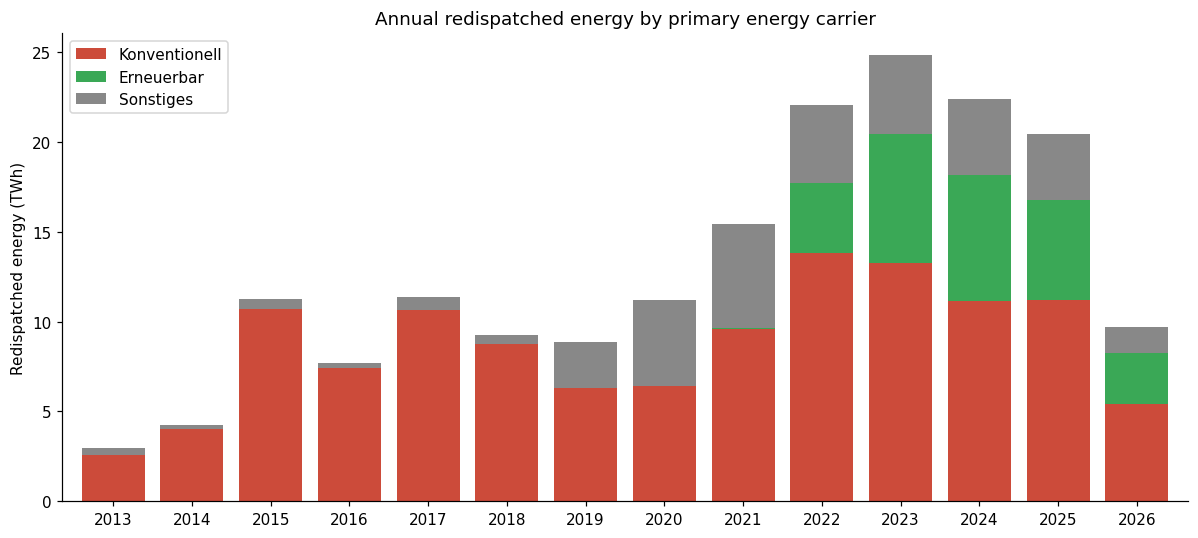

In [62]:
# Stacked YoY energy by source — the most informative view of the regime change.
src_yoy = (rd.dropna(subset=['year','PRIMAERENERGIEART'])
             .groupby(['year','PRIMAERENERGIEART'])['GESAMTE_ARBEIT_MWH']
             .sum().unstack(fill_value=0) / 1e6)  # TWh
src_yoy = src_yoy[[c for c in ['Konventionell','Erneuerbar','Sonstiges'] if c in src_yoy.columns]]

fig, ax = plt.subplots(figsize=(11, 5))
src_yoy.plot.bar(stacked=True, ax=ax,
                 color=[CARRIER_COLORS.get(c, '#888') for c in src_yoy.columns],
                 width=0.8)
ax.set_ylabel('Redispatched energy (TWh)')
ax.set_xlabel('')
ax.set_title('Annual redispatched energy by primary energy carrier')
ax.legend(loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 1.3 Intraday pattern — events by hour of day

Two angles:
- **Conventional** dispatches cluster on morning/evening ramp hours (load-shape driven, voltage support).
- **Renewables** peak midday (solar) or off-peak nights (wind, low-load curtailment risk).

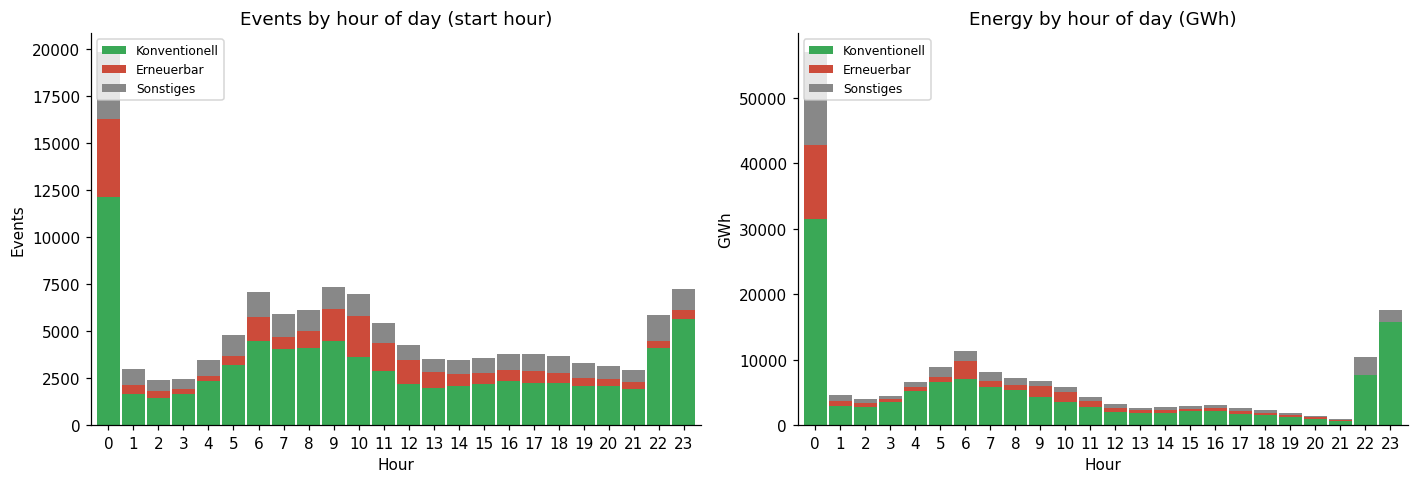

In [63]:
by_hour = (rd.dropna(subset=['hour'])
             .groupby(['hour','PRIMAERENERGIEART'])
             .agg(n_events=('GRUND_DER_MASSNAHME','size'),
                  energy_mwh=('GESAMTE_ARBEIT_MWH','sum'))
             .reset_index())

events_h = by_hour.pivot(index='hour', columns='PRIMAERENERGIEART', values='n_events').fillna(0)
energy_h = by_hour.pivot(index='hour', columns='PRIMAERENERGIEART', values='energy_mwh').fillna(0) / 1e3  # GWh

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
events_h[[c for c in ['Konventionell','Erneuerbar','Sonstiges'] if c in events_h.columns]].plot.bar(
    stacked=True, ax=axes[0],
    color=[CARRIER_COLORS[c] for c in events_h.columns if c in CARRIER_COLORS], width=0.9)
axes[0].set_title('Events by hour of day (start hour)')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Events')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

energy_h[[c for c in ['Konventionell','Erneuerbar','Sonstiges'] if c in energy_h.columns]].plot.bar(
    stacked=True, ax=axes[1],
    color=[CARRIER_COLORS[c] for c in energy_h.columns if c in CARRIER_COLORS], width=0.9)
axes[1].set_title('Energy by hour of day (GWh)')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('GWh')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

## 1.4 Seasonality — events by month

Wind-heavy season (Nov–Feb) drives most renewable-redispatch volume; solar feed-in in summer should show up as midday up-regulation of conventional plants. Look for the asymmetry.

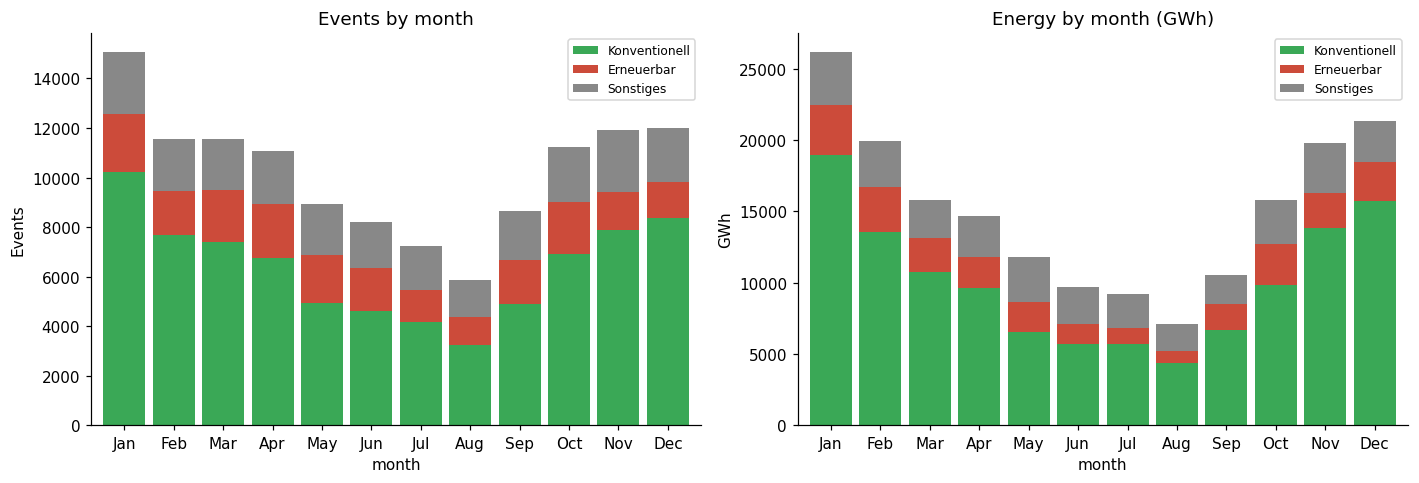

In [64]:
by_month = (rd.dropna(subset=['month'])
              .groupby(['month','PRIMAERENERGIEART'])
              .agg(n_events=('GRUND_DER_MASSNAHME','size'),
                   energy_mwh=('GESAMTE_ARBEIT_MWH','sum'))
              .reset_index())
evt_m = by_month.pivot(index='month', columns='PRIMAERENERGIEART', values='n_events').fillna(0)
eng_m = by_month.pivot(index='month', columns='PRIMAERENERGIEART', values='energy_mwh').fillna(0) / 1e3  # GWh

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
evt_m[[c for c in ['Konventionell','Erneuerbar','Sonstiges'] if c in evt_m.columns]].plot.bar(
    stacked=True, ax=axes[0],
    color=[CARRIER_COLORS[c] for c in evt_m.columns if c in CARRIER_COLORS], width=0.85)
axes[0].set_title('Events by month'); axes[0].set_ylabel('Events')
axes[0].set_xticklabels(MONTH_LABELS, rotation=0)
axes[0].legend(fontsize=8)

eng_m[[c for c in ['Konventionell','Erneuerbar','Sonstiges'] if c in eng_m.columns]].plot.bar(
    stacked=True, ax=axes[1],
    color=[CARRIER_COLORS[c] for c in eng_m.columns if c in CARRIER_COLORS], width=0.85)
axes[1].set_title('Energy by month (GWh)'); axes[1].set_ylabel('GWh')
axes[1].set_xticklabels(MONTH_LABELS, rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 1.5 Size distribution

Histogram of `MITTLERE_LEISTUNG_MW` per event, split by source. Both axes are log-scaled because the distribution is heavy-tailed — a few MW dominate by count, hundreds of MW dominate by total volume.

In [65]:
size_stats = (rd.groupby('PRIMAERENERGIEART')['MITTLERE_LEISTUNG_MW']
                .describe(percentiles=[.5, .9, .99])
                .round(1))
size_stats

,count,mean,std,min,50%,90%,99%,max
PRIMAERENERGIEART,,,,,,,,
Erneuerbar,21303.0,158.6,160.0,0.0,108.0,340.0,794.8,1599.2
Konventionell,77056.0,196.0,194.4,0.0,154.0,372.0,967.0,4338.0
Sonstiges,24926.0,180.4,217.8,0.0,100.0,416.7,1042.1,2174.8


C:\Users\wachs\AppData\Local\Temp\ipykernel_15872\3000993526.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=list(CARRIER_COLORS.keys()), showfliers=False, patch_artist=True)


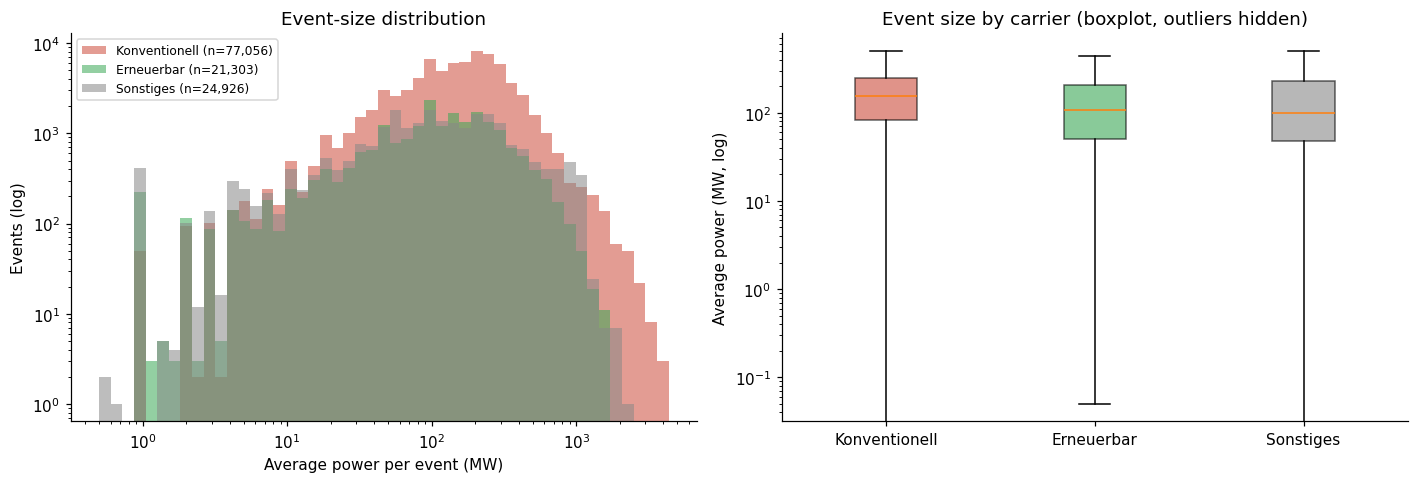

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.logspace(np.log10(0.5), np.log10(max(rd['MITTLERE_LEISTUNG_MW'].max(), 10)), 50)
for carrier, color in CARRIER_COLORS.items():
    s = rd.loc[rd['PRIMAERENERGIEART']==carrier, 'MITTLERE_LEISTUNG_MW'].dropna()
    if len(s):
        axes[0].hist(s, bins=bins, alpha=0.55, label=f'{carrier} (n={len(s):,})', color=color)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Average power per event (MW)')
axes[0].set_ylabel('Events (log)')
axes[0].set_title('Event-size distribution')
axes[0].legend(fontsize=8)

# Boxplot for the medians/quartiles
data = [rd.loc[rd['PRIMAERENERGIEART']==c, 'MITTLERE_LEISTUNG_MW'].dropna().values
        for c in CARRIER_COLORS]
bp = axes[1].boxplot(data, labels=list(CARRIER_COLORS.keys()), showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], CARRIER_COLORS.values()):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_yscale('log')
axes[1].set_ylabel('Average power (MW, log)')
axes[1].set_title('Event size by carrier (boxplot, outliers hidden)')

plt.tight_layout(); plt.show()

## 1.6 Duration distribution

How long does a single redispatch instruction run? Useful for sizing the storage opportunity — a battery covering 1-hour events is a different product from one covering 6-hour events.

                     count  mean   std     min  50%   90%   99%   max
PRIMAERENERGIEART                                                    
Erneuerbar         21303.0  6.72  6.20    0.25  5.0  17.0  24.0  24.0
Konventionell      77056.0  7.35  7.41 -741.00  5.0  19.0  24.0  33.5
Sonstiges          24926.0  6.09  6.85    0.25  3.0  18.0  24.0  24.0


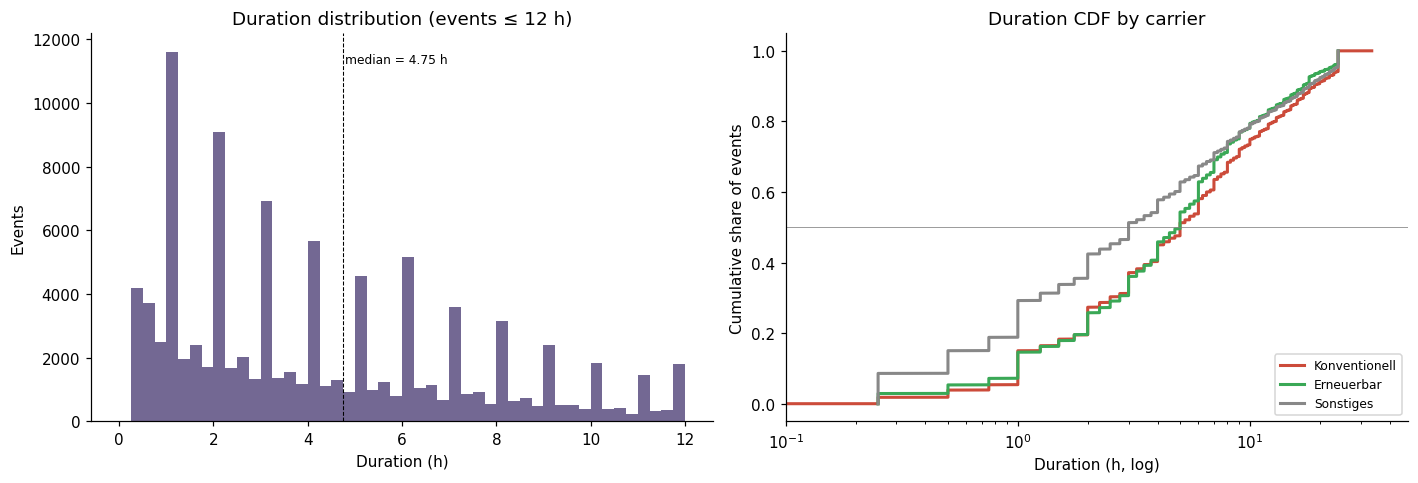

In [67]:
dur = rd['duration_h'].dropna()
dur = dur[(dur >= 0) & (dur <= 48)]  # drop a small number of garbage rows w/ negative or week-long durations

dur_stats = (rd.groupby('PRIMAERENERGIEART')['duration_h']
               .describe(percentiles=[.5, .9, .99]).round(2))
print(dur_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(dur, bins=np.linspace(0, 12, 49), color='#5a4d80', alpha=0.85)
axes[0].set_xlabel('Duration (h)'); axes[0].set_ylabel('Events')
axes[0].set_title('Duration distribution (events ≤ 12 h)')
axes[0].axvline(dur.median(), color='k', ls='--', lw=0.7)
axes[0].text(dur.median()+0.05, axes[0].get_ylim()[1]*0.95,
             f'median = {dur.median():.2f} h', fontsize=8, va='top')

# CDF — easier to read for sizing decisions
for carrier, color in CARRIER_COLORS.items():
    s = rd.loc[rd['PRIMAERENERGIEART']==carrier, 'duration_h'].dropna()
    s = s[(s >= 0) & (s <= 48)].sort_values()
    if len(s):
        axes[1].plot(s.values, np.arange(1, len(s)+1)/len(s),
                     label=carrier, color=color, lw=2)
axes[1].set_xscale('log')
axes[1].set_xlim(0.1, 48)
axes[1].set_xlabel('Duration (h, log)'); axes[1].set_ylabel('Cumulative share of events')
axes[1].set_title('Duration CDF by carrier')
axes[1].axhline(0.5, color='gray', lw=0.5)
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout(); plt.show()

### 1.6a Average duration by energy type

Direct comparison of how long a typical redispatch event runs for **Konventionell** vs **Erneuerbar** (and Sonstiges for completeness). Three views, because mean and median tell different stories with this heavy-tailed distribution:

- **arithmetic mean** — pulled up by the long tail of multi-day reserve-plant tests
- **median** — what a "typical" event looks like
- **energy-weighted mean** — the duration that actually carries the dispatched-energy total (each event's duration weighted by `GESAMTE_ARBEIT_MWH`)

The seminar-relevant question: do renewable curtailments tend to be shorter or longer than conventional dispatches? That changes the storage-duration product spec for any battery aiming to displace this volume.

                   n_events  mean_h  median_h  energy_wmean_h  p90_h
PRIMAERENERGIEART                                                   
Konventionell       76947.0    7.40       5.0           14.41   19.0
Erneuerbar          21303.0    6.72       5.0           14.11   17.0
Sonstiges           24926.0    6.09       3.0           16.08   18.0


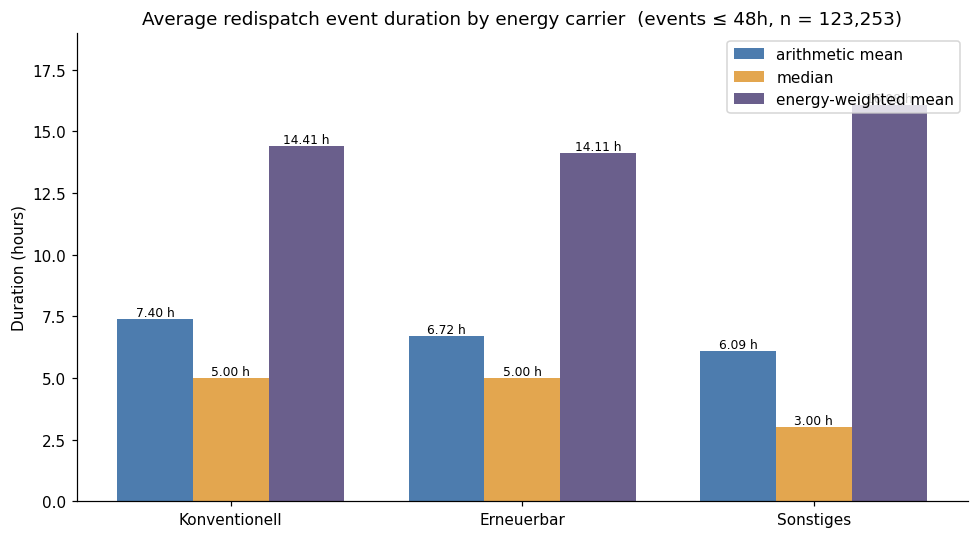

In [68]:
# Trim implausible durations: <0 (negative) or >48h (legacy multi-day rows
# from the pre-Redispatch-2.0 schema). These are <1% of rows but skew the mean.
dur_ok = rd[(rd['duration_h'] >= 0) & (rd['duration_h'] <= 48)].copy()

def per_carrier_stats(g):
    w = g['GESAMTE_ARBEIT_MWH'].fillna(0)
    wmean = np.average(g['duration_h'], weights=w) if w.sum() > 0 else np.nan
    return pd.Series({
        'n_events':         len(g),
        'mean_h':           g['duration_h'].mean(),
        'median_h':         g['duration_h'].median(),
        'energy_wmean_h':   wmean,
        'p90_h':            g['duration_h'].quantile(0.90),
    })

dur_by_carrier = (dur_ok.groupby('PRIMAERENERGIEART')[['duration_h', 'GESAMTE_ARBEIT_MWH']]
                        .apply(per_carrier_stats)
                        .round(2))
dur_by_carrier = dur_by_carrier.reindex(
    [c for c in ['Konventionell', 'Erneuerbar', 'Sonstiges'] if c in dur_by_carrier.index])
print(dur_by_carrier)

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['mean_h', 'median_h', 'energy_wmean_h']
metric_labels = ['arithmetic mean', 'median', 'energy-weighted mean']
metric_colors = ['#3a6ea5', '#e09d3c', '#5a4d80']
x = np.arange(len(dur_by_carrier))
bar_w = 0.26

for i, (col, lab, c) in enumerate(zip(metrics, metric_labels, metric_colors)):
    bars = ax.bar(x + (i - 1) * bar_w, dur_by_carrier[col], bar_w,
                  label=lab, color=c, alpha=0.9)
    for b, v in zip(bars, dur_by_carrier[col]):
        ax.annotate(f'{v:.2f} h',
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(dur_by_carrier.index)
ax.set_ylabel('Duration (hours)')
ax.set_title(f'Average redispatch event duration by energy carrier  '
             f'(events ≤ 48h, n = {len(dur_ok):,})')
ax.legend(loc='upper right')
ax.set_ylim(0, dur_by_carrier[metrics].values.max() * 1.18)
plt.tight_layout(); plt.show()

### 1.6b Year-over-year mean duration, by carrier × season

Same comparison year by year, with the winter / summer half-year split (DE convention: **Winterhalbjahr** Oct–Mar, **Sommerhalbjahr** Apr–Sep). Three panels stacked:

1. all events
2. winter half only (wind-dominated curtailment season)
3. summer half only (solar feed-in + maintenance season)

If renewable events get shorter year over year that's a sign the TSOs are using more frequent, surgical curtailments. If the winter–summer gap widens that's a signal the redispatch product is splitting into two different shapes.

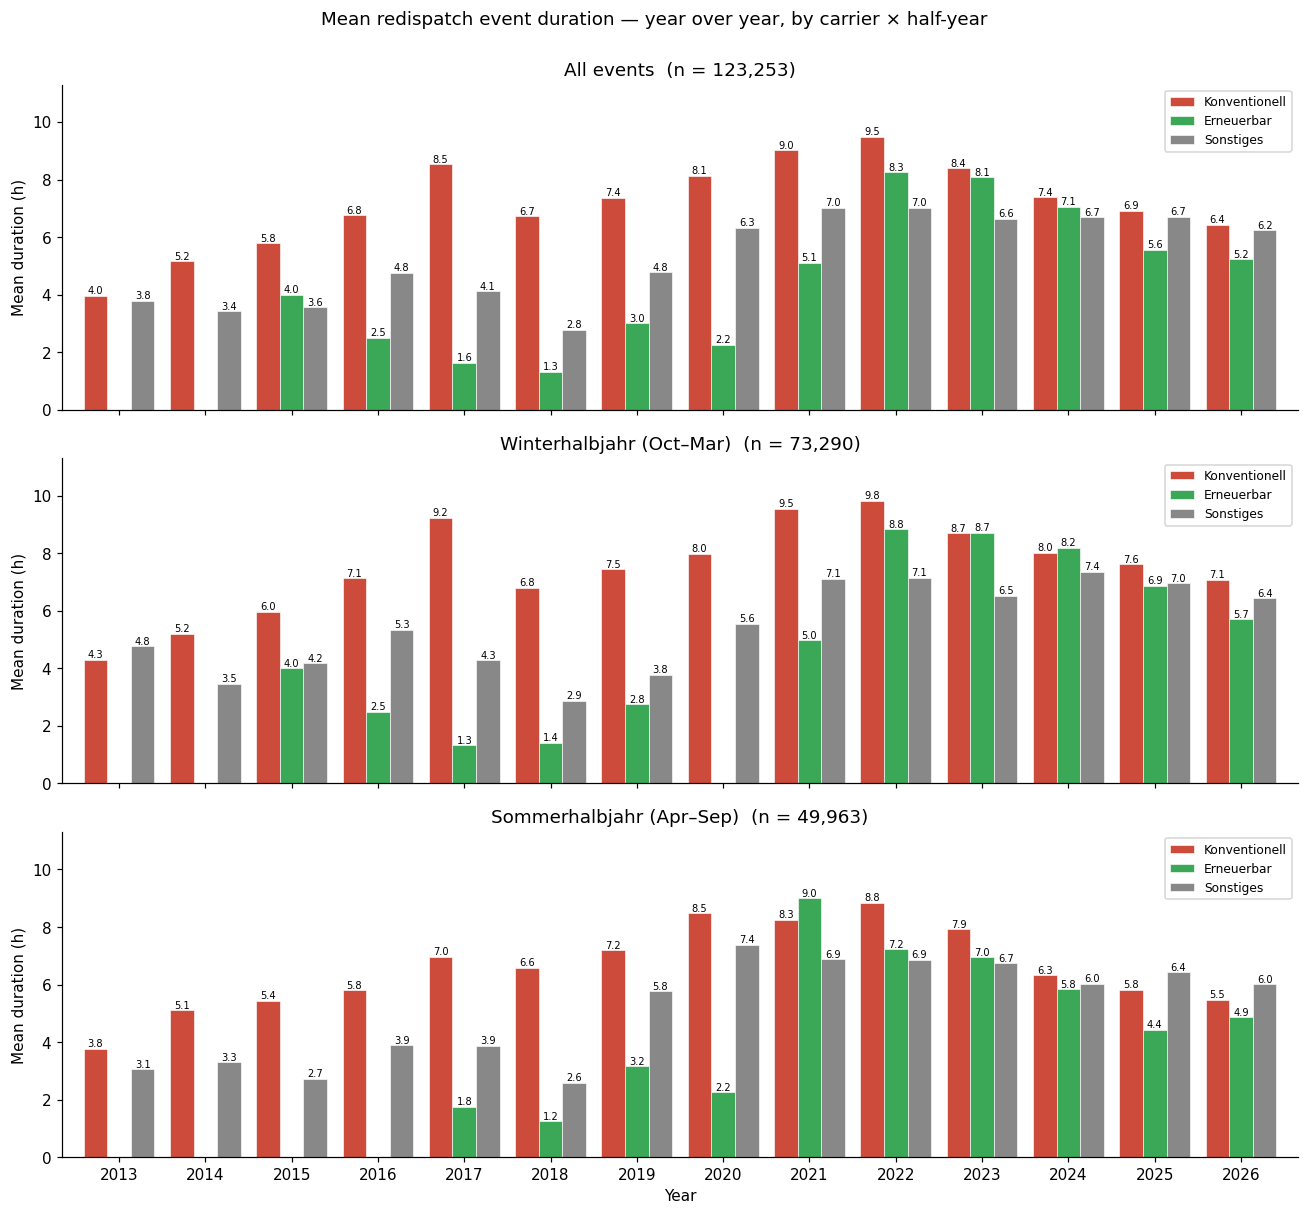

In [69]:
# Reuse the trimmed-duration frame from 1.6a
dur_ok['season'] = np.where(dur_ok['month'].isin([10, 11, 12, 1, 2, 3]),
                            'winter', 'summer')

CARRIERS_PLOT = ['Konventionell', 'Erneuerbar', 'Sonstiges']

def yoy_mean_duration(df_subset):
    return (df_subset.dropna(subset=['year'])
                     .groupby(['year', 'PRIMAERENERGIEART'])['duration_h']
                     .mean()
                     .unstack(fill_value=np.nan)
                     .reindex(columns=[c for c in CARRIERS_PLOT
                                       if c in df_subset['PRIMAERENERGIEART'].unique()]))

panels = [
    ('All events',              dur_ok),
    ('Winterhalbjahr (Oct–Mar)', dur_ok[dur_ok['season'] == 'winter']),
    ('Sommerhalbjahr (Apr–Sep)', dur_ok[dur_ok['season'] == 'summer']),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
ymax = max(yoy_mean_duration(df).max().max() for _, df in panels) * 1.15

for ax, (title, df) in zip(axes, panels):
    yoy = yoy_mean_duration(df)
    yoy.plot.bar(ax=ax,
                 color=[CARRIER_COLORS[c] for c in yoy.columns],
                 width=0.82, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{title}  (n = {len(df):,})')
    ax.set_ylabel('Mean duration (h)')
    ax.set_xlabel('')
    ax.set_ylim(0, ymax)
    ax.legend(title='', loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(f'{h:.1f}',
                        (p.get_x() + p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=6.5)

axes[-1].set_xlabel('Year')
fig.suptitle('Mean redispatch event duration — year over year, by carrier × half-year',
             y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

### 1.6c Why did mean duration rise until 2022 and then fall?

Decompose the redispatch volume identity:

$$\text{Energy} \;=\; \underbrace{N_{\text{events}}}_{\text{how often}} \;\times\; \underbrace{\bar d}_{\text{mean duration}} \;\times\; \underbrace{\bar P}_{\text{mean power per event}}$$

Hypothesis: Redispatch 2.0 (Oct 2021) brought a flood of *smaller* DSO-connected assets into the regime. Through the transition (2021–2022) each TSO instruction had to coordinate more units and ran longer; once the new workflow matured the TSOs could use **more, shorter, surgically targeted** events. So:

- $N$ keeps growing → drives total energy up
- $\bar d$ overshoots in the transition years, then falls back as the tooling matures
- $\bar P$ falls because smaller assets joined the addressable pool

The two panels below test that:
1. **Absolute YoY** of all four quantities — the raw shape of each component
2. **Indexed to 2013** — each line shows how many times bigger that component is vs the base year. The decomposition only works if `N × d × P ≈ Energy`, so the green (events) × blue (duration) × orange (power) line product should track the purple (energy) line.

      n_events  mean_duration_h  implied_mean_mw  energy_twh
year                                                        
2013      2659             3.94           274.93        2.88
2014      3386             4.88           241.87        4.00
2015      6460             5.52           315.78       11.25
2016      4057             6.54           292.18        7.75
2017      5808             7.92           251.28       11.55
2018      5526             6.13           274.88        9.31
2019      5321             6.39           261.23        8.89
2020      6792             7.38           223.37       11.20
2021      8634             8.23           217.00       15.42
2022     12705             8.63           201.17       22.06
2023     15185             7.95           205.58       24.81
2024     17390             7.16           179.62       22.37
2025     19369             6.48           162.98       20.46
2026      9961             6.05           160.96        9.70


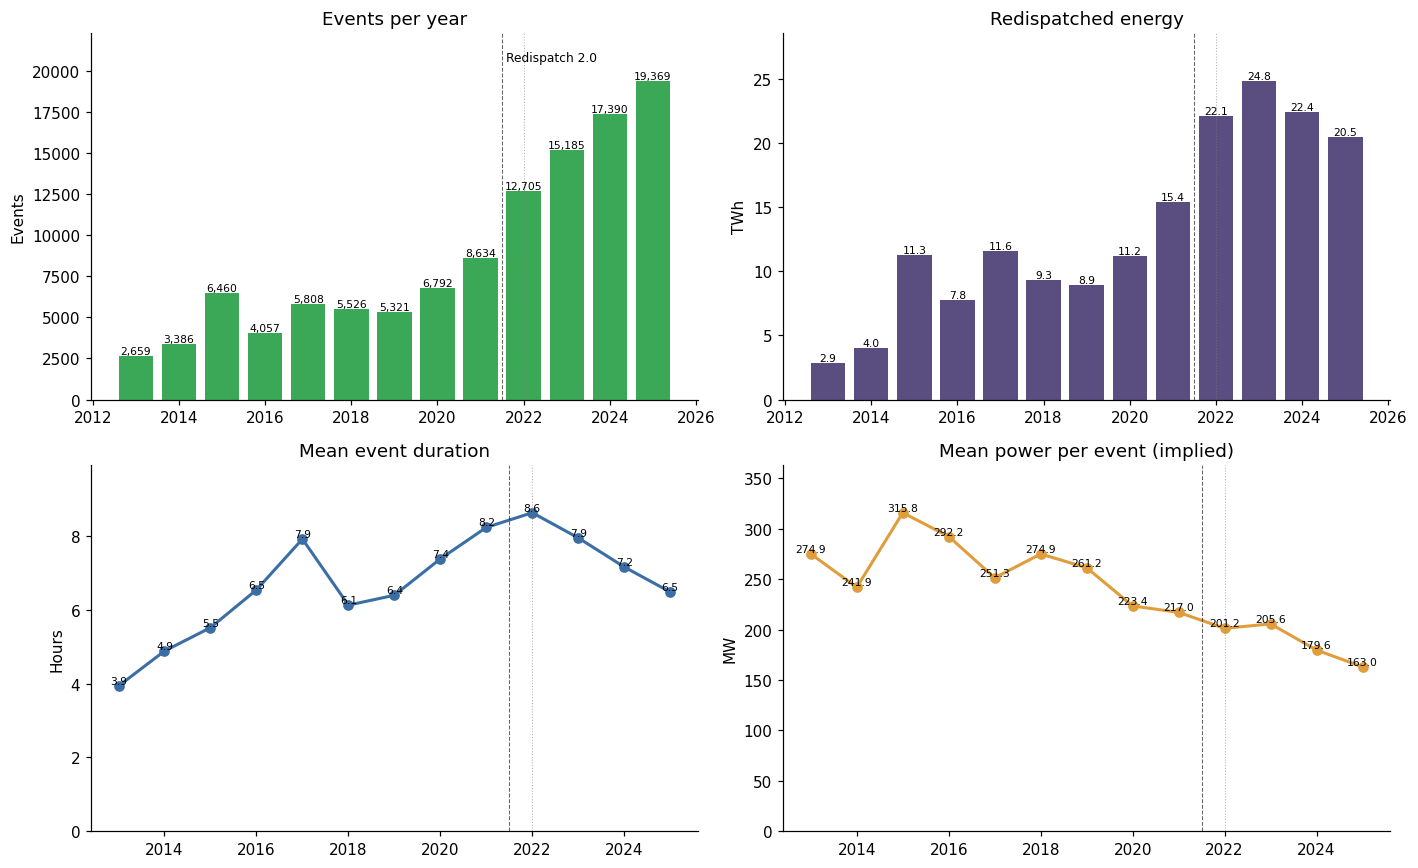

In [70]:
# YoY decomposition. Use the trimmed-duration frame (consistent with 1.6a/b).
yoy_dec = (dur_ok.dropna(subset=['year'])
                  .groupby('year')
                  .agg(n_events=('GRUND_DER_MASSNAHME', 'size'),
                       mean_duration_h=('duration_h', 'mean'),
                       energy_mwh=('GESAMTE_ARBEIT_MWH', 'sum')))
# Implied mean power: solving energy = N × duration × P for P
yoy_dec['implied_mean_mw'] = (yoy_dec['energy_mwh'] /
                              (yoy_dec['n_events'] * yoy_dec['mean_duration_h']))
yoy_dec['energy_twh'] = yoy_dec['energy_mwh'] / 1e6
print(yoy_dec[['n_events', 'mean_duration_h', 'implied_mean_mw', 'energy_twh']].round(2))

# Drop partial years from the bar/line plots to avoid misreading them
CURRENT_YEAR = 2026
yoy_full = yoy_dec[yoy_dec.index < CURRENT_YEAR]

# ---- Figure A: absolute YoY ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
PEAK = 2022  # where mean duration peaked

panel_specs = [
    (axes[0,0], 'n_events',         'Events per year',           'Events',            '#3aa856', False),
    (axes[0,1], 'energy_twh',       'Redispatched energy',       'TWh',               '#5a4d80', False),
    (axes[1,0], 'mean_duration_h',  'Mean event duration',       'Hours',             '#3a6ea5', True),
    (axes[1,1], 'implied_mean_mw',  'Mean power per event (implied)', 'MW',           '#e09d3c', True),
]
for ax, col, title, ylab, color, as_line in panel_specs:
    if as_line:
        ax.plot(yoy_full.index, yoy_full[col], '-o', color=color, lw=2)
    else:
        ax.bar(yoy_full.index, yoy_full[col], color=color)
    ax.set_title(title); ax.set_ylabel(ylab)
    ax.axvline(2021.5, color='k', ls='--', lw=0.7, alpha=0.6)
    ax.axvline(PEAK + 0.0, color='gray', ls=':', lw=0.7, alpha=0.6)
    fmt = (lambda v: f'{v:.1f}') if as_line else (lambda v: f'{int(v):,}' if col=='n_events' else f'{v:.1f}')
    for x, v in zip(yoy_full.index, yoy_full[col]):
        ax.annotate(fmt(v), (x, v), ha='center', va='bottom', fontsize=7)
    ax.set_ylim(0, yoy_full[col].max()*1.15)
axes[0,0].text(2021.6, axes[0,0].get_ylim()[1]*0.95, 'Redispatch 2.0', fontsize=8, va='top')
plt.tight_layout(); plt.show()

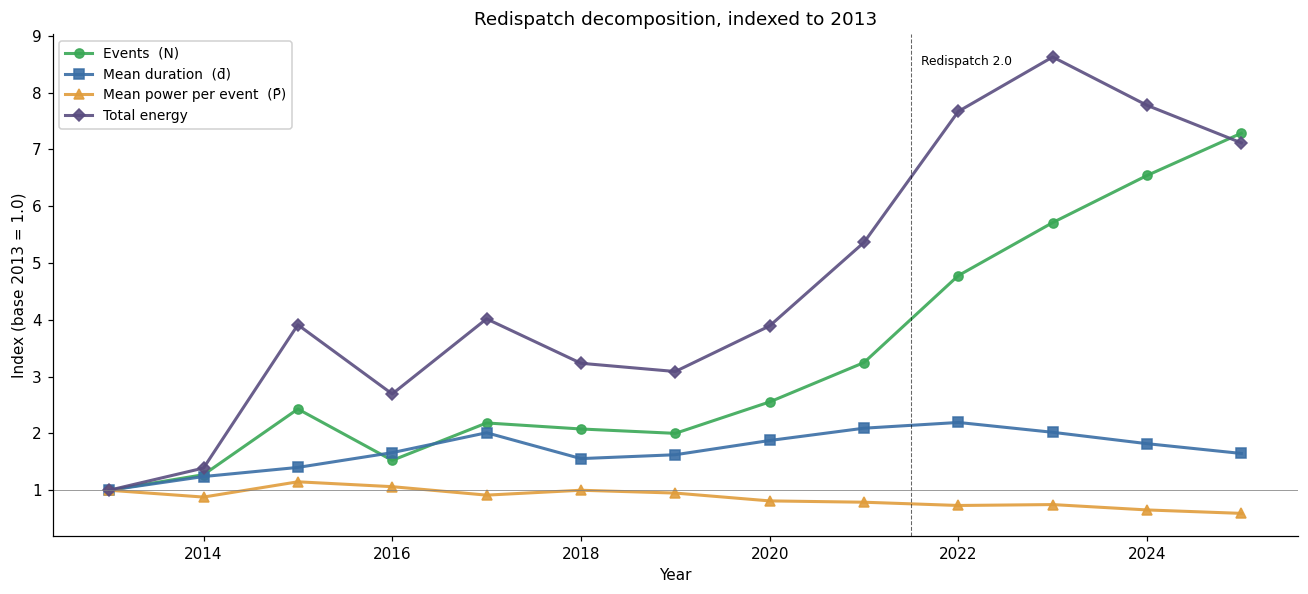

Snapshot (2013 -> duration peak 2022 -> 2025):
      n_events  mean_duration_h  implied_mean_mw  energy_twh
year                                                        
2013      2659             3.94            274.9        2.88
2022     12705             8.63            201.2       22.06
2025     19369             6.48            163.0       20.46


In [71]:
# ---- Figure B: indexed to base year — the decomposition view ----
BASE = yoy_full.index.min()
idx = yoy_full[['n_events', 'mean_duration_h', 'implied_mean_mw', 'energy_twh']] / \
      yoy_full[['n_events', 'mean_duration_h', 'implied_mean_mw', 'energy_twh']].iloc[0]

fig, ax = plt.subplots(figsize=(12, 5.5))
style = {
    'n_events':         ('Events  (N)',                  '#3aa856', '-o'),
    'mean_duration_h':  ('Mean duration  (d̄)',           '#3a6ea5', '-s'),
    'implied_mean_mw':  ('Mean power per event  (P̄)',    '#e09d3c', '-^'),
    'energy_twh':       ('Total energy',                  '#5a4d80', '-D'),
}
for col, (label, color, marker) in style.items():
    ax.plot(idx.index, idx[col], marker, color=color, lw=2, ms=6,
            label=label, alpha=0.9)

ax.axvline(2021.5, color='k', ls='--', lw=0.7, alpha=0.6)
ax.text(2021.6, ax.get_ylim()[1]*0.96, 'Redispatch 2.0', fontsize=8, va='top')
ax.axhline(1.0, color='gray', lw=0.5)

ax.set_ylabel(f'Index (base {BASE} = 1.0)')
ax.set_xlabel('Year')
ax.set_title(f'Redispatch decomposition, indexed to {BASE}')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()

# Snapshot table: base year, duration-peak year, latest full year
LATEST = yoy_full.index.max()
peak_year = int(yoy_full['mean_duration_h'].idxmax())
summary = yoy_full.loc[[BASE, peak_year, LATEST]].copy()
summary['energy_twh'] = summary['energy_twh'].round(2)
summary['mean_duration_h'] = summary['mean_duration_h'].round(2)
summary['implied_mean_mw'] = summary['implied_mean_mw'].round(1)
print(f'Snapshot ({BASE} -> duration peak {peak_year} -> {LATEST}):')
print(summary[['n_events', 'mean_duration_h', 'implied_mean_mw', 'energy_twh']])

### 1.6d Same decomposition, split by direction

Same chart, run separately for **positive** events (up-regulation — `Wirkleistungseinspeisung erhöhen`, plant ramps up) and **negative** events (down-regulation — `... reduzieren`, curtailment). If the duration overshoot is driven by curtailment side, we'll see the duration line spike harder in the down-regulation panel.

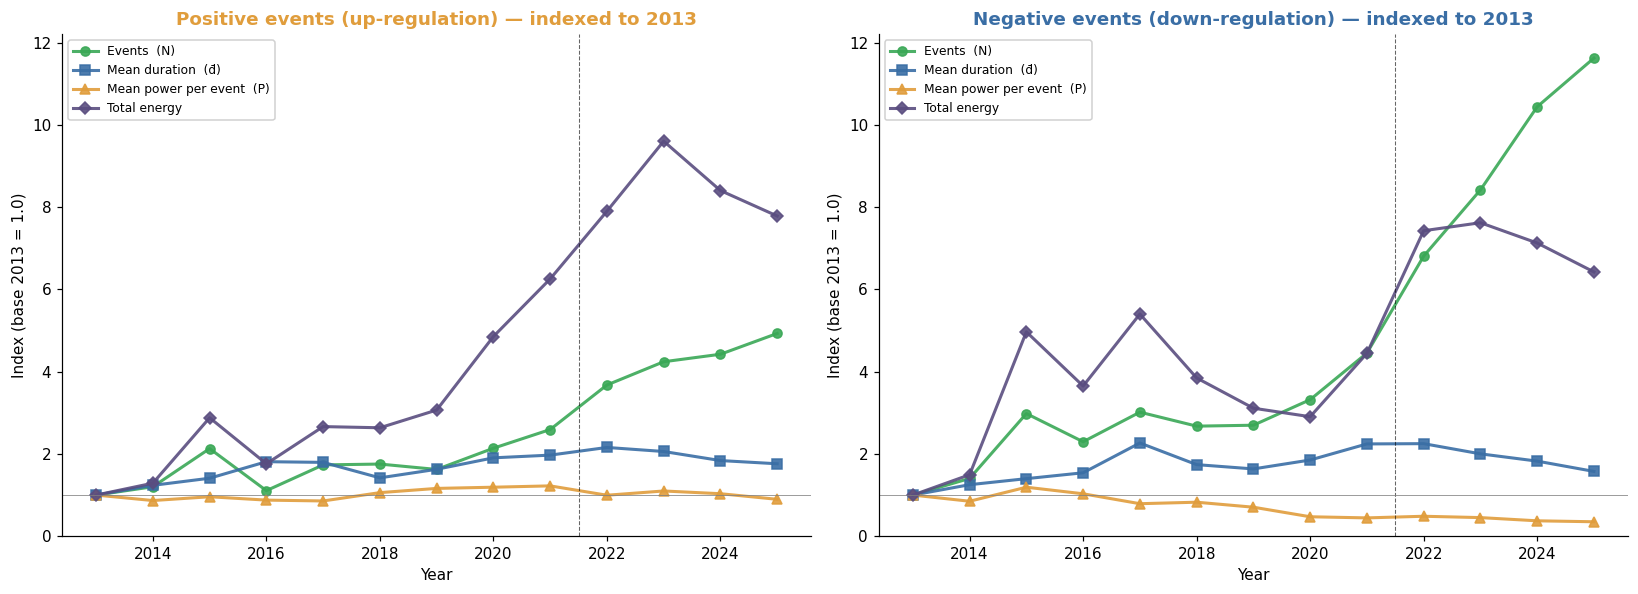


Positive events (up-regulation)  (2013 -> peak 2022 -> 2025)
      n_events  mean_duration_h  implied_mean_mw  energy_twh
year                                                        
2013      1724             3.98           212.27        1.46
2022      6338             8.58           211.44       11.50
2025      8499             7.01           190.35       11.33

Negative events (down-regulation)  (2013 -> peak 2017 -> 2025)
      n_events  mean_duration_h  implied_mean_mw  energy_twh
year                                                        
2013       935             3.86           394.10        1.42
2017      2820             8.74           311.39        7.68
2025     10870             6.07           138.29        9.13


In [72]:
def _dir(s):
    if not isinstance(s, str): return None
    if 'erh' in s:  return 'up'
    if 'redu' in s: return 'down'
    return None

dur_ok['direction'] = dur_ok['RICHTUNG'].map(_dir)

def yoy_decomp(subset):
    yoy = (subset.dropna(subset=['year'])
                  .groupby('year')
                  .agg(n_events=('GRUND_DER_MASSNAHME', 'size'),
                       mean_duration_h=('duration_h', 'mean'),
                       energy_mwh=('GESAMTE_ARBEIT_MWH', 'sum')))
    yoy['implied_mean_mw'] = yoy['energy_mwh'] / (yoy['n_events'] * yoy['mean_duration_h'])
    yoy['energy_twh'] = yoy['energy_mwh'] / 1e6
    return yoy[yoy.index < CURRENT_YEAR]

panels = [
    ('Positive events (up-regulation)',  dur_ok[dur_ok['direction'] == 'up'],   '#e09d3c'),
    ('Negative events (down-regulation)', dur_ok[dur_ok['direction'] == 'down'], '#3a6ea5'),
]

style_d = {
    'n_events':         ('Events  (N)',                '#3aa856', '-o'),
    'mean_duration_h':  ('Mean duration  (d̄)',         '#3a6ea5', '-s'),
    'implied_mean_mw':  ('Mean power per event  (P̄)',  '#e09d3c', '-^'),
    'energy_twh':       ('Total energy',                '#5a4d80', '-D'),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
y_top = 0
for ax, (title, sub, accent) in zip(axes, panels):
    yoy = yoy_decomp(sub)
    base_year = int(yoy.index.min())
    idx = yoy[list(style_d)] / yoy[list(style_d)].iloc[0]
    for col, (lab, color, marker) in style_d.items():
        ax.plot(idx.index, idx[col], marker, color=color, lw=2, ms=6, label=lab, alpha=0.9)
    ax.axvline(2021.5, color='k', ls='--', lw=0.7, alpha=0.6)
    ax.axhline(1.0, color='gray', lw=0.5)
    ax.set_title(f'{title} — indexed to {base_year}', color=accent, fontweight='bold')
    ax.set_ylabel(f'Index (base {base_year} = 1.0)')
    ax.set_xlabel('Year')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    y_top = max(y_top, idx.max().max())

for ax in axes:
    ax.set_ylim(0, y_top * 1.05)

plt.tight_layout(); plt.show()

# Snapshot tables for each direction
for title, sub, _ in panels:
    yoy = yoy_decomp(sub)
    base, peak, latest = int(yoy.index.min()), int(yoy['mean_duration_h'].idxmax()), int(yoy.index.max())
    snap = yoy.loc[[base, peak, latest], ['n_events', 'mean_duration_h', 'implied_mean_mw', 'energy_twh']].round(2)
    print(f'\n{title}  ({base} -> peak {peak} -> {latest})')
    print(snap)

---

# Part 2 — Matched events (regional + congestion)

Restrict to events whose `BETROFFENE_ANLAGE` joined to a row in `plant_matcher_output.xlsx` with `final_lat`/`final_lon`. That subset is the one we can put on a map.

In [73]:
matcher = pd.read_excel(MATCHER_FILE)
matcher_slim = matcher[['plant_name', 'primaerenergieart',
                        'final_lat', 'final_lon', 'final_confidence']].rename(
    columns={'final_lat': 'lat', 'final_lon': 'lon',
             'primaerenergieart': 'carrier_matcher'})

m = rd.merge(matcher_slim, left_on='BETROFFENE_ANLAGE',
             right_on='plant_name', how='inner')
m = m.dropna(subset=['lat', 'lon']).copy()
m['carrier'] = m['carrier_matcher'].fillna(m['PRIMAERENERGIEART'])
print(f'matched + geocoded events: {len(m):,}  ({len(m)/len(rd):.1%} of all)')
print(f'matched plants           : {m["plant_name"].nunique():,}')
print(f'matched energy           : {m["GESAMTE_ARBEIT_MWH"].sum()/1e6:.1f} TWh '
      f'({m["GESAMTE_ARBEIT_MWH"].sum()/rd["GESAMTE_ARBEIT_MWH"].sum():.1%} of total)')

matched + geocoded events: 101,793  (82.5% of all)
matched plants           : 685
matched energy           : 139.0 TWh (76.4% of total)


## 2.1 By TSO zone

`ANWEISENDER_UENB` is the natural redispatch region — each zone has its own grid topology, generation mix, and bottlenecks. 50Hertz (east) and TenneT (north–south corridor) carry the brunt of wind-driven congestion.

In [74]:
by_tso = (m.groupby('ANWEISENDER_UENB')
            .agg(n_events=('GRUND_DER_MASSNAHME','size'),
                 energy_twh=('GESAMTE_ARBEIT_MWH', lambda s: s.sum()/1e6),
                 n_plants=('plant_name','nunique'),
                 avg_mw=('MITTLERE_LEISTUNG_MW','mean'))
            .sort_values('energy_twh', ascending=False)
            .round(2))
by_tso

,n_events,energy_twh,n_plants,avg_mw
ANWEISENDER_UENB,,,,
TenneT DE,35667,54.31,224,177.22
TransnetBW,21806,29.09,72,171.51
50Hertz,25047,28.03,178,168.42
Amprion,19273,27.59,211,181.62


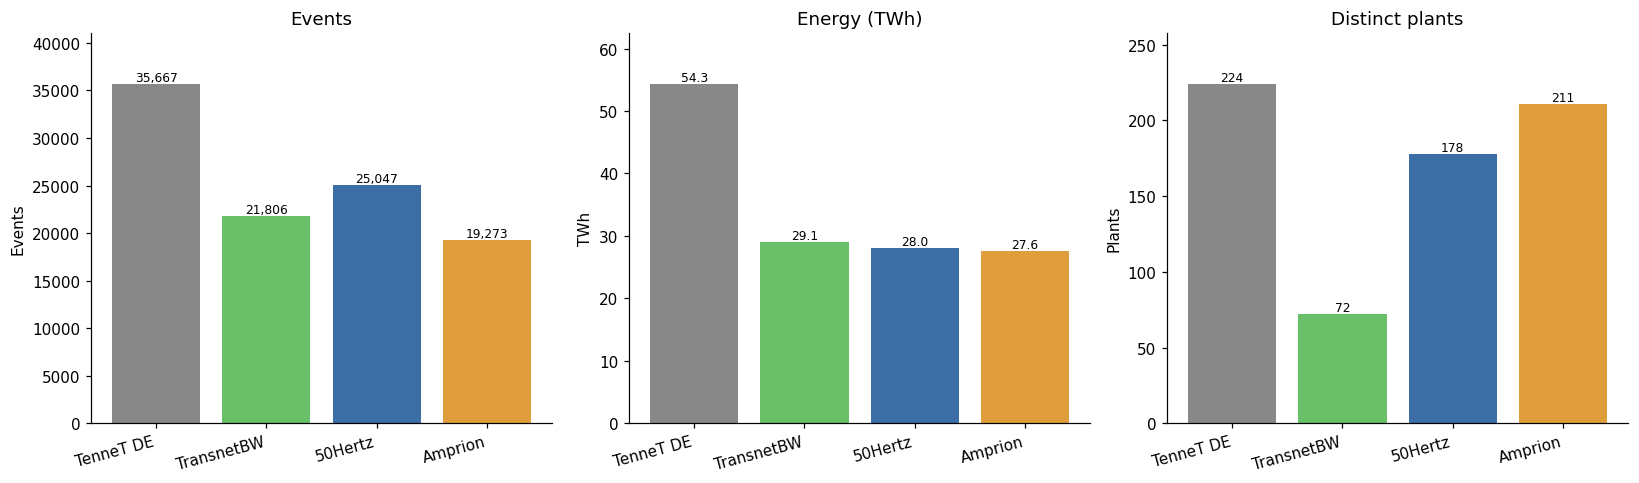

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title, ylab in zip(
    axes,
    ['n_events','energy_twh','n_plants'],
    ['Events','Energy (TWh)','Distinct plants'],
    ['Events','TWh','Plants']):
    colors = [TSO_COLORS.get(t, '#888') for t in by_tso.index]
    ax.bar(by_tso.index, by_tso[col], color=colors)
    ax.set_title(title); ax.set_ylabel(ylab)
    for i, v in enumerate(by_tso[col]):
        ax.annotate(f'{v:,.1f}' if col=='energy_twh' else f'{int(v):,}',
                    (i, v), ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, by_tso[col].max()*1.15)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout(); plt.show()

### 2.1a Carrier mix per TSO

50Hertz has wind-heavy curtailment; TransnetBW does a lot of conventional voltage RD; Amprion/TenneT sit in between.

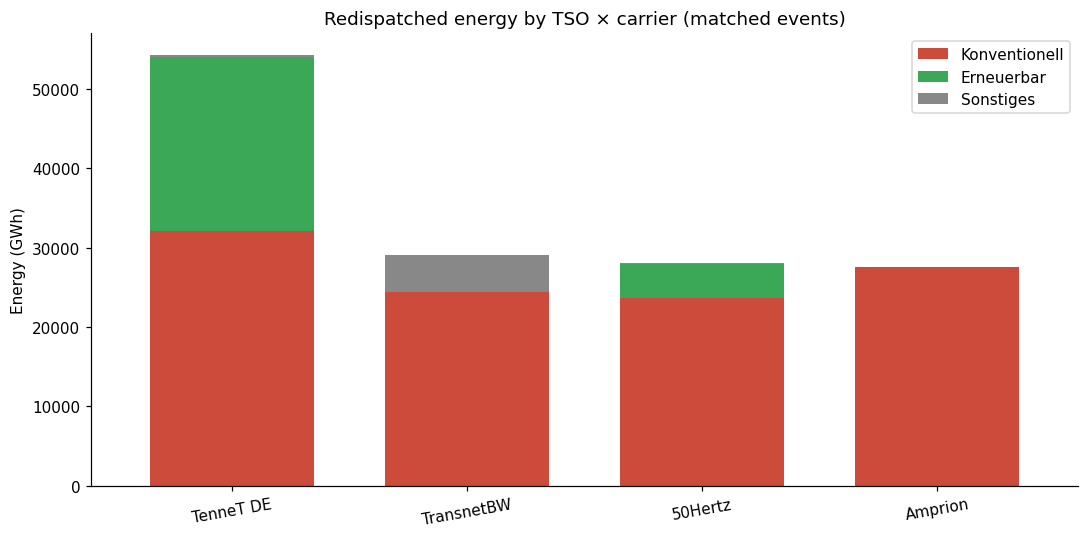

In [76]:
tso_carrier = (m.groupby(['ANWEISENDER_UENB','carrier'])['GESAMTE_ARBEIT_MWH']
                 .sum().unstack(fill_value=0) / 1e3)  # GWh
tso_carrier = tso_carrier.reindex(by_tso.index)
tso_carrier = tso_carrier[[c for c in CARRIER_COLORS if c in tso_carrier.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
tso_carrier.plot.bar(stacked=True, ax=ax,
                     color=[CARRIER_COLORS[c] for c in tso_carrier.columns],
                     width=0.7)
ax.set_ylabel('Energy (GWh)')
ax.set_xlabel('')
ax.set_title('Redispatched energy by TSO × carrier (matched events)')
plt.xticks(rotation=10)
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 2.2 North / Centre / South split

Cuts the matched plants into three latitude bands as a quick north→south stress view:
- **North** (≥ 52° N): SH, HH, NI-north, MV, much of Brandenburg → wind-export region
- **Centre** (49.5°–52° N): central Germany, the bottleneck zone
- **South** (< 49.5° N): BY, BW → load centre, low onshore wind

Approximation, not a political map — but it lines up with the "North-South redispatch corridor" framing.

In [77]:
def lat_band(lat: float) -> str:
    if lat >= 52.0:  return 'North'
    if lat >= 49.5:  return 'Centre'
    return 'South'

m['region'] = m['lat'].map(lat_band)
REGION_ORDER = ['North', 'Centre', 'South']
REGION_COLORS = {'North': '#3a6ea5', 'Centre': '#e09d3c', 'South': '#cc4b3a'}

by_region = (m.groupby('region')
               .agg(n_events=('GRUND_DER_MASSNAHME','size'),
                    energy_twh=('GESAMTE_ARBEIT_MWH', lambda s: s.sum()/1e6),
                    n_plants=('plant_name','nunique'))
               .reindex(REGION_ORDER).round(2))
by_region

,n_events,energy_twh,n_plants
region,,,
North,33449,48.61,237
Centre,39206,51.67,284
South,29138,38.73,164


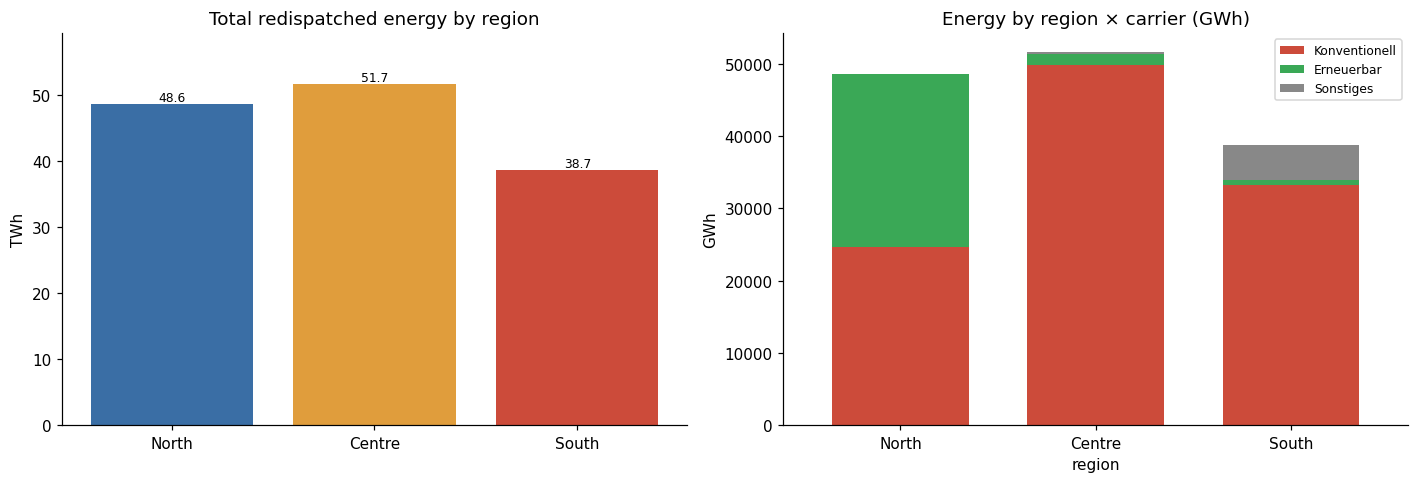

In [78]:
reg_carrier = (m.groupby(['region','carrier'])['GESAMTE_ARBEIT_MWH']
                .sum().unstack(fill_value=0).reindex(REGION_ORDER) / 1e3)  # GWh
reg_carrier = reg_carrier[[c for c in CARRIER_COLORS if c in reg_carrier.columns]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(by_region.index, by_region['energy_twh'],
            color=[REGION_COLORS[r] for r in by_region.index])
axes[0].set_title('Total redispatched energy by region')
axes[0].set_ylabel('TWh')
for i, v in enumerate(by_region['energy_twh']):
    axes[0].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0, by_region['energy_twh'].max()*1.15)

reg_carrier.plot.bar(stacked=True, ax=axes[1],
                     color=[CARRIER_COLORS[c] for c in reg_carrier.columns],
                     width=0.7)
axes[1].set_title('Energy by region × carrier (GWh)')
axes[1].set_ylabel('GWh')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

## 2.3 Direction of redispatch by region

`Wirkleistungseinspeisung erhöhen` = up-regulation (plant ramps up), `... reduzieren` = down-regulation (curtailment). In a textbook north→south congestion event the TSO **down-regulates** in the north (excess wind) and **up-regulates** in the south.

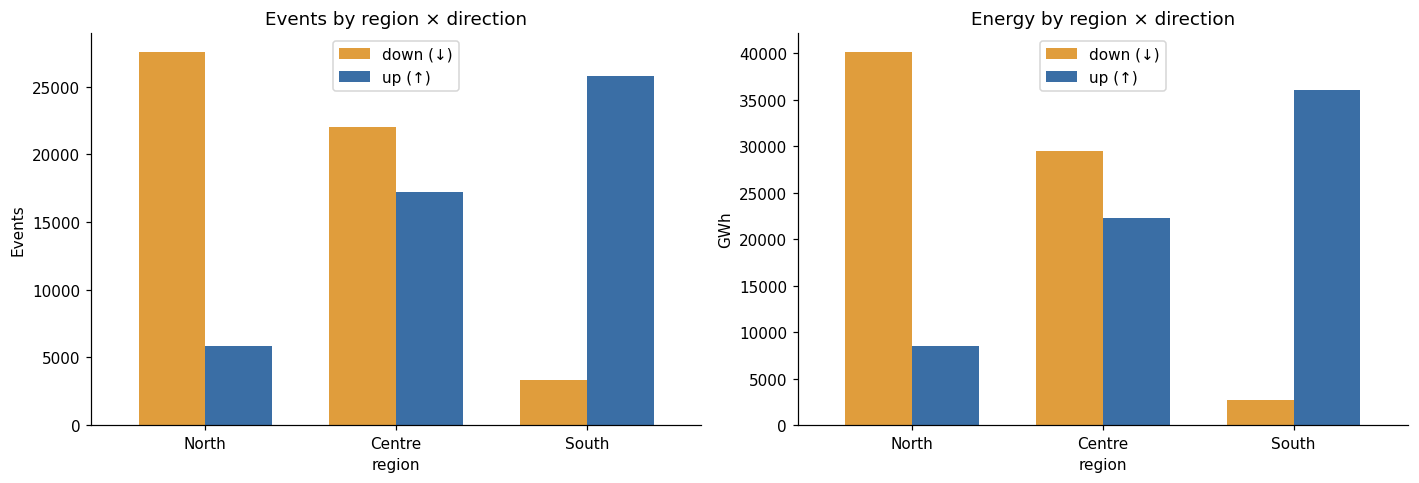

Net energy (up − down) by region [GWh]:
region
North    -31635.0
Centre    -7191.9
South     33252.0
dtype: float64


In [79]:
# Map the German RICHTUNG values to short labels.
def dir_short(s):
    if not isinstance(s, str): return None
    if 'erh' in s: return 'up (↑)'
    if 'redu' in s: return 'down (↓)'
    return s
m['direction'] = m['RICHTUNG'].map(dir_short)

reg_dir_energy = (m.groupby(['region','direction'])['GESAMTE_ARBEIT_MWH']
                    .sum().unstack(fill_value=0).reindex(REGION_ORDER) / 1e3)  # GWh
reg_dir_events = (m.groupby(['region','direction']).size()
                    .unstack(fill_value=0).reindex(REGION_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
dir_colors = ['#e09d3c', '#3a6ea5']  # up, down

reg_dir_events.plot.bar(ax=axes[0], color=dir_colors, width=0.7)
axes[0].set_title('Events by region × direction'); axes[0].set_ylabel('Events')
axes[0].tick_params(axis='x', rotation=0); axes[0].legend(title='')

reg_dir_energy.plot.bar(ax=axes[1], color=dir_colors, width=0.7)
axes[1].set_title('Energy by region × direction'); axes[1].set_ylabel('GWh')
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(title='')

plt.tight_layout(); plt.show()

# Net balance — negative means net curtailment, positive means net ramp-up
net = reg_dir_energy.get('up (↑)', 0) - reg_dir_energy.get('down (↓)', 0)
print('Net energy (up − down) by region [GWh]:')
print(net.round(1))

## 2.4 Heaviest congested locations — top plants

The 20 plants that accumulate the most dispatched energy. Conventional units in the south (TransnetBW reserve fleet) and offshore wind clusters in the north show up here.

In [80]:
top_plants = (m.groupby(['plant_name','carrier','region'])
                .agg(energy_gwh=('GESAMTE_ARBEIT_MWH', lambda s: s.sum()/1e3),
                     n_events=('GRUND_DER_MASSNAHME','size'))
                .sort_values('energy_gwh', ascending=False)
                .head(20).reset_index())
top_plants

,plant_name,carrier,region,energy_gwh,n_events
0,Rheinhafen-Dampfkraftwerk Karlsruhe Block 8,Konventionell,South,6125.64849,2015
1,Wilhelmshaven (ENGIE),Konventionell,North,6123.23107,1861
2,OWP UW Büttel,Erneuerbar,North,5971.87325,1867
3,OWP UW Dörpen-West,Erneuerbar,North,5348.74781,1888
4,Staudinger 5,Konventionell,Centre,3941.53225,2104
5,Schwarze Pumpe (Standort),Konventionell,Centre,3345.63900,2182
6,Rheinhafen-Dampfkraftwerk Karlsruhe Block 7,Konventionell,South,3299.57550,1560
7,Heizkraftwerk Heilbronn Block 7,Konventionell,South,3084.62750,1284
8,Emsland Block D,Konventionell,North,2981.99800,1050
9,"Boxberg,Jänschwalde,Lippendorf Vattenfall (EPH...",Konventionell,Centre,2434.49200,441


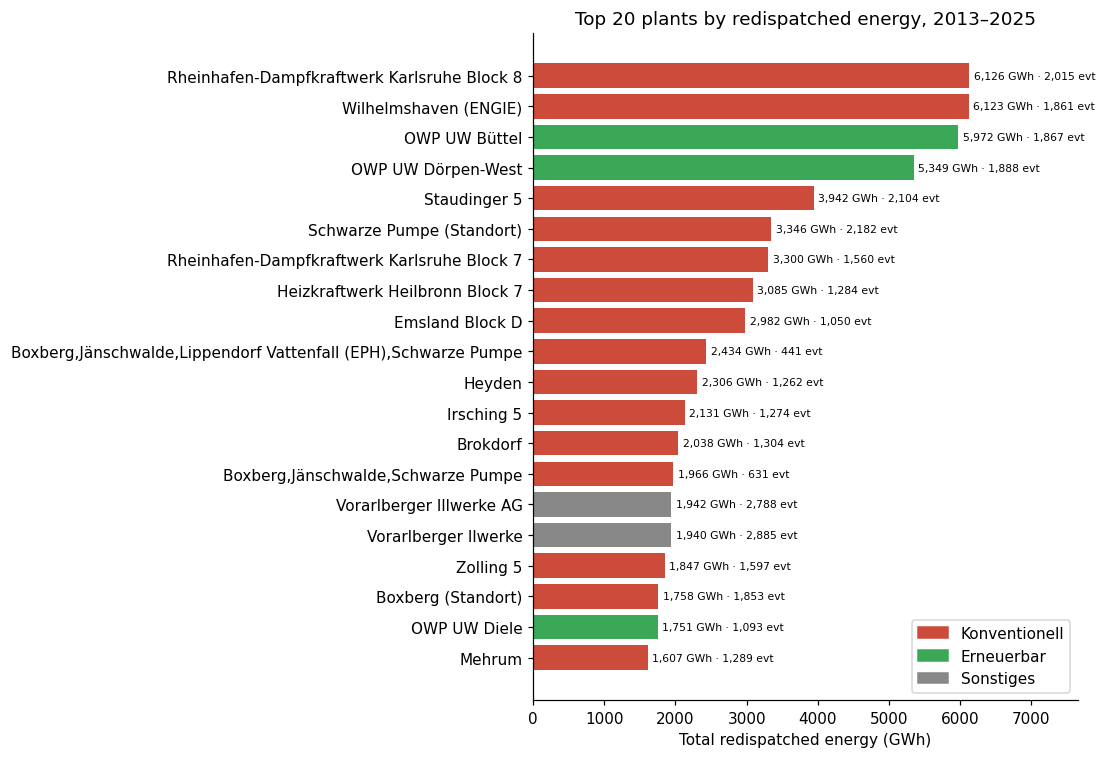

In [81]:
fig, ax = plt.subplots(figsize=(10, 7))
tp = top_plants.iloc[::-1]
ax.barh(tp['plant_name'], tp['energy_gwh'],
        color=[CARRIER_COLORS.get(c, '#888') for c in tp['carrier']])
ax.set_xlabel('Total redispatched energy (GWh)')
ax.set_title('Top 20 plants by redispatched energy, 2013–2025')
for i, (name, e, n) in enumerate(zip(tp['plant_name'], tp['energy_gwh'], tp['n_events'])):
    ax.annotate(f'{e:,.0f} GWh · {int(n):,} evt',
                (e, i), ha='left', va='center', fontsize=7,
                xytext=(3, 0), textcoords='offset points')
handles = [plt.Rectangle((0,0),1,1, color=c) for c in CARRIER_COLORS.values()]
ax.legend(handles, CARRIER_COLORS.keys(), loc='lower right')
ax.set_xlim(0, tp['energy_gwh'].max()*1.25)
plt.tight_layout(); plt.show()

## 2.5 Spatial heatmap — where the congestion physically sits

Hexbin of total redispatched energy weighted by `GESAMTE_ARBEIT_MWH`. The bright cells are the structural hotspots — Lusatia coal cluster, Rhine-Ruhr, the Bavarian gas fleet, the offshore-import corridors.

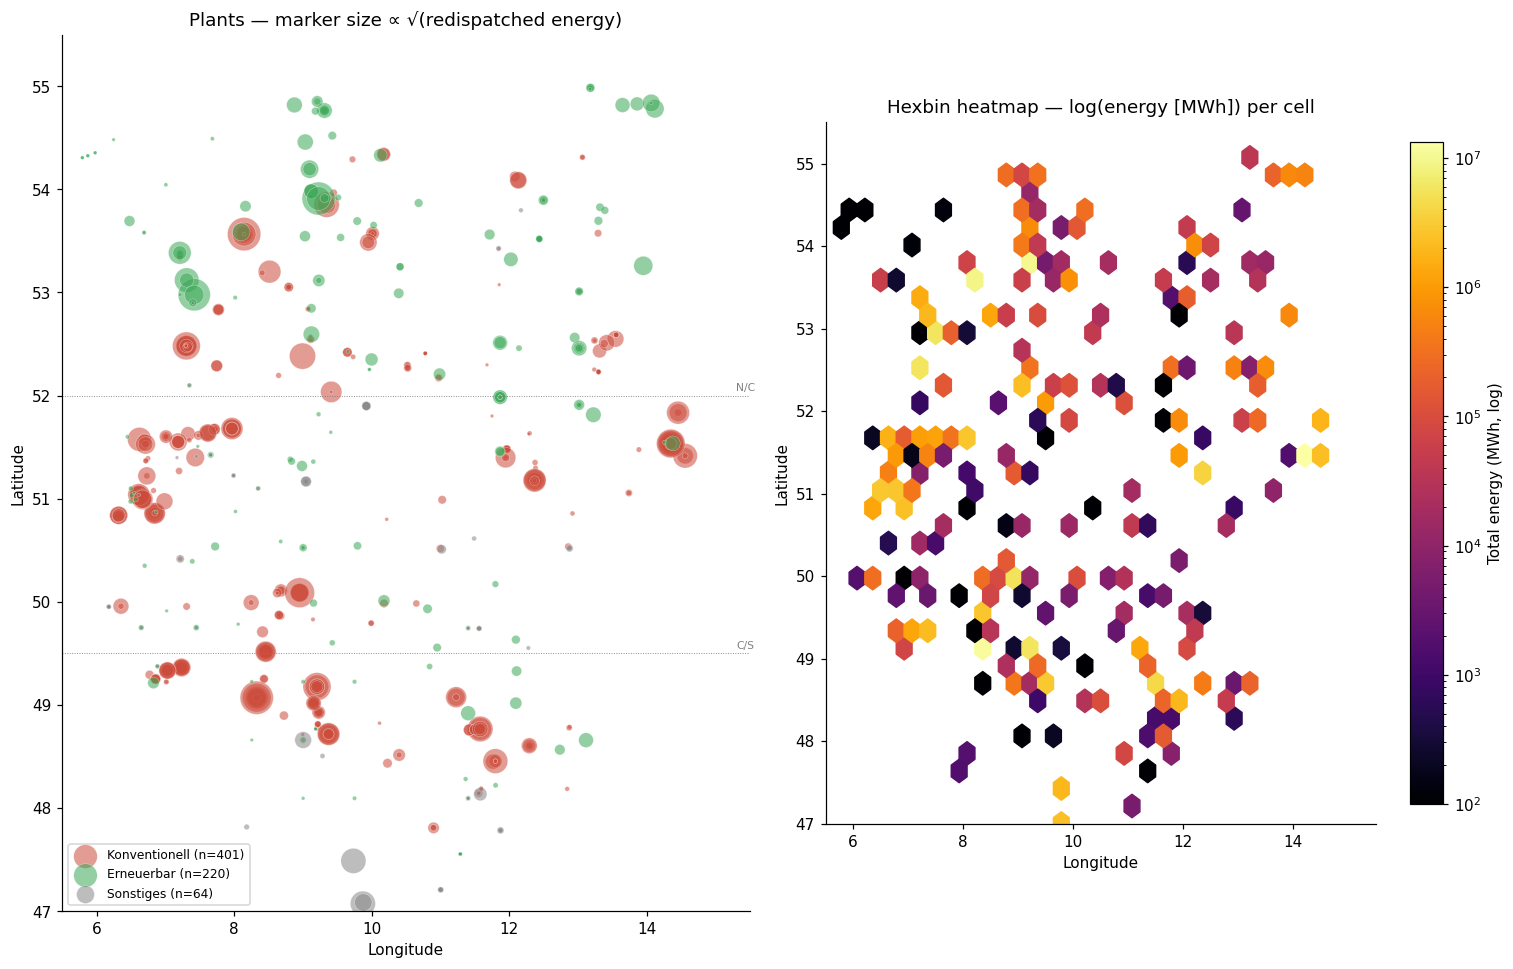

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

# Plant-level scatter, sized by energy, coloured by carrier
g = (m.groupby(['plant_name','lat','lon','carrier'])['GESAMTE_ARBEIT_MWH']
       .sum().reset_index(name='energy_mwh'))
g['energy_gwh'] = g['energy_mwh'] / 1e3
for carrier, color in CARRIER_COLORS.items():
    sub = g[g['carrier'] == carrier]
    axes[0].scatter(sub['lon'], sub['lat'],
                    s=np.sqrt(sub['energy_gwh']) * 6 + 5,
                    c=color, alpha=0.55, edgecolor='white', linewidth=0.3,
                    label=f'{carrier} (n={len(sub)})')
axes[0].axhline(52.0, color='gray', ls=':', lw=0.6)
axes[0].axhline(49.5, color='gray', ls=':', lw=0.6)
axes[0].text(15.3, 52.05, 'N/C', fontsize=7, color='gray')
axes[0].text(15.3, 49.55, 'C/S', fontsize=7, color='gray')
axes[0].set_xlim(5.5, 15.5); axes[0].set_ylim(47.0, 55.5)
axes[0].set_aspect(1.5)
axes[0].set_title('Plants — marker size ∝ √(redispatched energy)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].legend(loc='lower left', fontsize=8)

# Hexbin weighted by energy (log scale)
hb = axes[1].hexbin(m['lon'], m['lat'],
                    C=m['GESAMTE_ARBEIT_MWH'], reduce_C_function=np.sum,
                    gridsize=35, cmap='inferno', norm=LogNorm(vmin=1e2),
                    mincnt=1, extent=(5.5, 15.5, 47.0, 55.5))
axes[1].set_xlim(5.5, 15.5); axes[1].set_ylim(47.0, 55.5)
axes[1].set_aspect(1.5)
axes[1].set_title('Hexbin heatmap — log(energy [MWh]) per cell')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
plt.colorbar(hb, ax=axes[1], shrink=0.7, label='Total energy (MWh, log)')

plt.tight_layout(); plt.show()

## 2.6 Direction map — up vs down hotspots

Two separate hexbins: one weighted by *up*-regulation energy, one by *down*. The classic redispatch pattern is **red in the north, blue in the south** — wind curtailed up north, gas/coal ramped up down south.

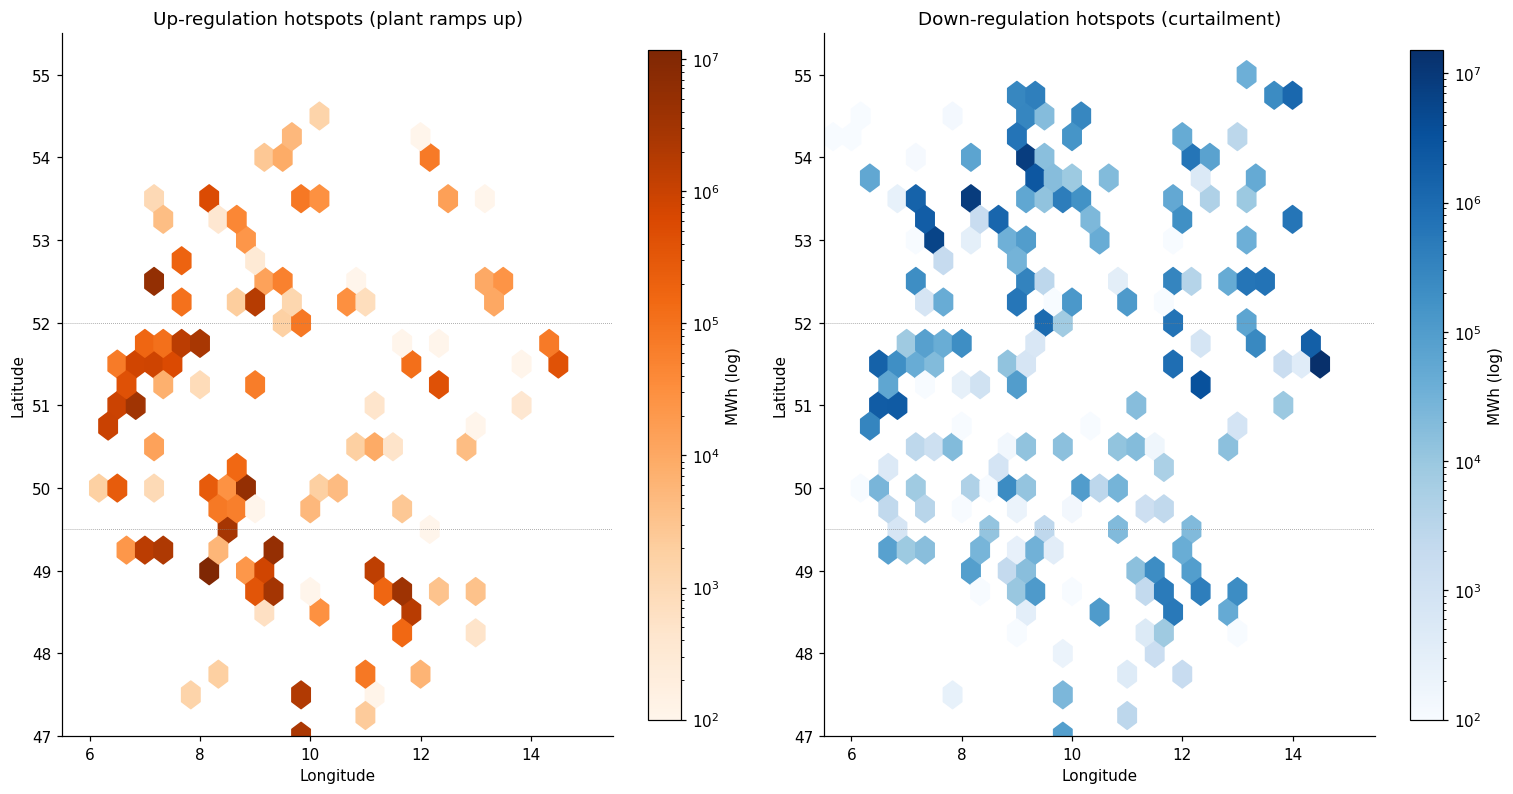

In [83]:
up = m[m['direction'] == 'up (↑)']
down = m[m['direction'] == 'down (↓)']

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
for ax, sub, title, cmap in zip(
    axes, [up, down],
    ['Up-regulation hotspots (plant ramps up)',
     'Down-regulation hotspots (curtailment)'],
    ['Oranges', 'Blues']):
    hb = ax.hexbin(sub['lon'], sub['lat'],
                   C=sub['GESAMTE_ARBEIT_MWH'], reduce_C_function=np.sum,
                   gridsize=30, cmap=cmap, norm=LogNorm(vmin=1e2),
                   mincnt=1, extent=(5.5, 15.5, 47.0, 55.5))
    ax.set_xlim(5.5, 15.5); ax.set_ylim(47.0, 55.5); ax.set_aspect(1.5)
    ax.set_title(title)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.axhline(52.0, color='gray', ls=':', lw=0.5)
    ax.axhline(49.5, color='gray', ls=':', lw=0.5)
    plt.colorbar(hb, ax=ax, shrink=0.7, label='MWh (log)')
plt.tight_layout(); plt.show()

## 2.7 Summary

In [84]:
summary = pd.Series({
    'total events': len(rd),
    'total energy (TWh)': rd['GESAMTE_ARBEIT_MWH'].sum() / 1e6,
    'matched events (geocoded)': len(m),
    'matched energy (TWh)': m['GESAMTE_ARBEIT_MWH'].sum() / 1e6,
    'distinct matched plants': m['plant_name'].nunique(),
    'energy coverage of matched subset': m['GESAMTE_ARBEIT_MWH'].sum()/rd['GESAMTE_ARBEIT_MWH'].sum(),
    'north share of matched energy': m.loc[m['region']=='North','GESAMTE_ARBEIT_MWH'].sum()/m['GESAMTE_ARBEIT_MWH'].sum(),
    'centre share': m.loc[m['region']=='Centre','GESAMTE_ARBEIT_MWH'].sum()/m['GESAMTE_ARBEIT_MWH'].sum(),
    'south share': m.loc[m['region']=='South','GESAMTE_ARBEIT_MWH'].sum()/m['GESAMTE_ARBEIT_MWH'].sum(),
})
summary.round(3).to_frame('value')

,value
total events,123362.000
total energy (TWh),182.034
matched events (geocoded),101793.000
matched energy (TWh),139.014
distinct matched plants,685.000
energy coverage of matched subset,0.764
north share of matched energy,0.350
centre share,0.372
south share,0.279
